# **WSINDy with Scattering Data: Results**

This notebook illustrates the Weak SINDy algorithm being applied to simulated KdV scattering data.

---

The examples are ordered:
- unperturbed, single soliton
- unperturbed, two-soliton collision
- perturbed, single soliton
- perturbed, two-soliton collision

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from netCDF4 import Dataset
from scipy.integrate import solve_ivp
from IPython.display import display,Math

from wsindy_ode import *
from compute_scattering_data import scattering_data_sequence
from recreate_results_helpers import *

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

In [2]:
# Plot settings
import matplotlib

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

#### **SINGLE SOLITON (UNPERTURBED)**

For a single KDV soliton: $$\begin{align*}
  \begin{cases}
    \dot{\kappa} = 0,\\
    \tfrac{d}{dt}\log(c) = 8\kappa^3.
  \end{cases}
\end{align*}$$

In [3]:
import os

# Stack three simulations
config_files = ['outputs/kdv_single_soliton_v0.nc',  # kappa = 2.0
                'outputs/kdv_single_soliton_v1.nc',  # kappa = 2.2
                'outputs/kdv_single_soliton_v2.nc']  # kappa = 2.4

# Add noise?
noise = 0.0
#noise = 0.20

# Cache the data (only recomputes when noise changes)
cache = f'outputs/stacked_states_single_soliton_noise{noise:g}.pt'
if os.path.exists(cache):
  blob = torch.load(cache)
  stacked_states, t = blob['stacked_states'], blob['t']
else:
  stacked_states = []
  for path in config_files:
    x, t_np, U_star = load_kdv_field(path)
    states, _ = scattering_series(x, U_star, t_np, noise=noise, min_kappa=0.4)
    stacked_states.append(states)
  t = torch.tensor(t_np, dtype=torch.float64)
  torch.save({'stacked_states': stacked_states, 't': t}, cache)

In [4]:
names = [r'\kappa', r'\log(c)']
beta = [[0,0], [1,0], [2,0], [3,0], # 1, k, k^2, k^3
        [0,1], [0,2], [0,3], [1,1]] # log(c), (log(c))^2, (log(c))^3, k * log(c)

models, odes, coeffs = fit_wsindy_bic_stacked(stacked_states, t, names, beta, m=[20], p=[10], s=[1], rescale=False, trigger_BIC='poor_fit')

100%|██████████| 1/1 [00:00<00:00, 420.27it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 480
Num. terms = 8
cond(G) = 2.475e+16

RESULTS
ODE: \kappa_{t} = 
Nonzero terms = 0
Rel. L2 error = 1.000
R^2 = -0.000
Lambda = 1.000e-04
Loss = 1.000
gamma^2 = 8.043
BIC triggered = True
BIC Delta = 14.338


100%|██████████| 1/1 [00:00<00:00, 803.51it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 480
Num. terms = 8
cond(G) = 2.084e+16

RESULTS
ODE: \log(c)_{t} = + 8.00(\kappa^3)
Nonzero terms = 1
Rel. L2 error = 0.000
R^2 = 1.000
Lambda = 4.292e-03
Loss = 0.125
gamma^2 = 8.043
BIC triggered = False
BIC Delta = n/a (not triggered)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
coeffs[1][-2].item()

7.9980609266835545

In [6]:
# Compare against the exact scattering ODEs
w_true = [torch.zeros(len(beta)), torch.tensor([0., 0., 0., 0., 0., 0., 8., 0.])]
w_found = torch.cat([w for w in coeffs])
w_truth = torch.cat(w_true)

# Known-model metrics
TPR = compute_tpr(w_found, w_truth)
nonzero = w_truth != 0
E_inf = ((w_found - w_truth).abs()[nonzero] / w_truth.abs()[nonzero]).max().item()

print(f'TPR = {TPR:.3f}')
print(f'E_inf = {E_inf:.3e}')

TPR = 1.000
E_inf = 2.424e-04


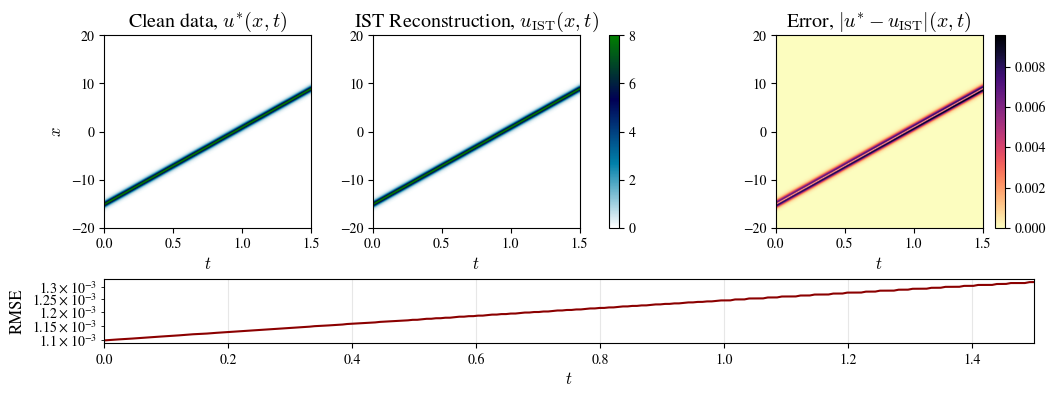

Total RMSE = 1.210e-03


In [7]:
# Forecast discovered model and IST to recover the field
x, _, U_star = load_kdv_field('outputs/kdv_single_soliton_v0.nc')
total_rmse, rmse_t, U_IST = RMSE_of_forecast(stacked_states[0], U_star, x, t, coeffs, beta, plot=True)

print(f'Total RMSE = {total_rmse:.3e}')

#### **TWO-SOLITON COLLISION (UNPERTURBED)**

For a system of two KDV solitons: $$\begin{align*}
  \begin{cases}
    \dot{\kappa}_i = 0,\\
    \tfrac{d}{dt}\log(c_i) = 8\kappa_i^3,
  \end{cases}
  \quad \text{for both} \quad
  i = 1, 2.
\end{align*}$$

In [8]:
import os

# Stack three two-soliton collision simulations
n_solitons = 2
config_files = ['outputs/kdv_soliton_collision_v0.nc',  # (kappa_1, kappa_2) = (2.4, 1.2)
                'outputs/kdv_soliton_collision_v1.nc',  # (kappa_1, kappa_2) = (2.0, 1.8)
                'outputs/kdv_soliton_collision_v2.nc']  # (kappa_1, kappa_2) = (2.2, 1.4)

# Add noise?
noise = 0.0
#noise = 0.20

# Cache the data (only recomputes when noise changes)
cache = f'outputs/stacked_states_two_soliton_noise{noise:g}.pt'
if os.path.exists(cache):
  blob = torch.load(cache)
  sim_states, t = blob['sim_states'], blob['t']
else:
  sim_states = []
  for path in config_files:
    x, t_np, U_star = load_kdv_field(path)
    states, _ = scattering_series_n(x, U_star, t_np, n_solitons, noise=noise, min_kappa=0.5)
    sim_states.append(states)
  t = torch.tensor(t_np, dtype=torch.float64)
  torch.save({'sim_states': sim_states, 't': t}, cache)

# Each soliton obeys the same ODE, so pool as a two-state system.
stacked_states = []
for states in sim_states:
  for i in range(n_solitons):
    stacked_states.append([states[i], states[n_solitons + i]])

In [9]:
names = [r'\kappa', r'\log(c)']
beta = [[0,0], [1,0], [2,0], [3,0], # 1, k, k^2, k^3
        [0,1], [0,2], [0,3], [1,1]] # log(c), (log(c))^2, (log(c))^3, k * log(c)

models, odes, coeffs = fit_wsindy_bic_stacked(stacked_states, t, names, beta, m=[20], p=[10], s=[1], rescale=False, trigger_BIC='poor_fit')

100%|██████████| 1/1 [00:00<00:00, 967.54it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 960
Num. terms = 8
cond(G) = 5.228e+06

RESULTS
ODE: \kappa_{t} = 
Nonzero terms = 0
Rel. L2 error = 1.000
R^2 = -0.000
Lambda = 3.556e-03
Loss = 1.000
gamma^2 = 16.085
BIC triggered = True
BIC Delta = 21.636


100%|██████████| 1/1 [00:00<00:00, 502.85it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 960
Num. terms = 8
cond(G) = 5.228e+06

RESULTS
ODE: \log(c)_{t} = + 8.00(\kappa^3)
Nonzero terms = 1
Rel. L2 error = 0.000
R^2 = 1.000
Lambda = 3.728e-04
Loss = 0.125
gamma^2 = 16.085
BIC triggered = False
BIC Delta = n/a (not triggered)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [10]:
coeffs[1][-2].item()

7.998437829025322

In [11]:
# Compare against the exact scattering ODEs
w_true = [torch.zeros(len(beta)), torch.tensor([0., 0., 0., 0., 0., 0., 8., 0.])]
w_found = torch.cat([w for w in coeffs])
w_truth = torch.cat(w_true)

# Known-model metrics
TPR = compute_tpr(w_found, w_truth)
nonzero = w_truth != 0
E_inf = ((w_found - w_truth).abs()[nonzero] / w_truth.abs()[nonzero]).max().item()

print(f'TPR = {TPR:.3f}')
print(f'E_inf = {E_inf:.3e}')

TPR = 1.000
E_inf = 1.953e-04


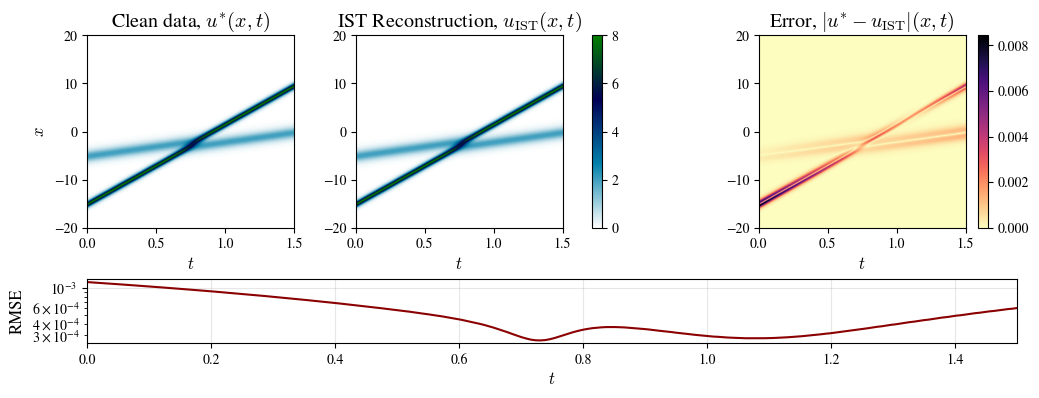

Total RMSE = 5.985e-04


In [12]:
# Forecast discovered model and IST to recover the field
x, _, U_star = load_kdv_field('outputs/kdv_soliton_collision_v0.nc')
total_rmse, rmse_t, U_IST = RMSE_of_forecast_pooled(sim_states[0], U_star, x, t, coeffs, beta, n_solitons, plot=True)

print(f'Total RMSE = {total_rmse:.3e}')

#### **SINGLE SOLITON (PERTURBED)**

For a single KDV soliton forced by $F(u) = \epsilon (xu)_x$: $$\begin{align*}
  \begin{cases}
    \dot{\kappa} = \frac{1}{3}\epsilon\kappa + \mathcal{O}(\epsilon^2),\\
    \tfrac{d}{dt}\log(c) = 8\kappa^3 - \frac{2}{3}\epsilon\log(c) + \mathcal{O}(\epsilon^2).
  \end{cases}
\end{align*}$$

In [15]:
import os

# Stack three perturbed single soliton simulations
config_files = ['outputs/kdv_single_soliton_perturbed_v0.nc',  # kappa = 2.0
                'outputs/kdv_single_soliton_perturbed_v1.nc',  # kappa = 2.2
                'outputs/kdv_single_soliton_perturbed_v2.nc']  # kappa = 2.4

# Add noise?
noise = 0.0
#noise = 0.20

# Cache the data (only recomputes when noise changes)
cache = f'outputs/stacked_states_single_soliton_perturbed_noise{noise:g}.pt'
if os.path.exists(cache):
  blob = torch.load(cache)
  stacked_states, t = blob['stacked_states'], blob['t']
else:
  stacked_states = []
  for path in config_files:
    x, t_np, U_star = load_kdv_field(path)
    states, _ = scattering_series(x, U_star, t_np, noise=noise, min_kappa=0.5)
    stacked_states.append(states)
  t = torch.tensor(t_np, dtype=torch.float64)
  torch.save({'stacked_states': stacked_states, 't': t}, cache)

In [16]:
names = [r'\kappa', r'\log(c)']
beta = [[1,0], [2,0], [3,0],
        [0,1], [0,2], [0,3]]
        
_, _, w_kappa = fit_wsindy_bic_stacked_eq(stacked_states, t, names, beta, eq=0, m=[20], p=[10], s=[1], rescale=False, trigger_BIC='poor_fit')
_, _, w_logc  = fit_wsindy_bic_stacked_eq(stacked_states, t, names, beta, eq=1, m=[20], p=[10], s=[1], rescale=False, trigger_BIC='poor_fit', Lambda=4e-2)

coeffs = [w_kappa, w_logc]

100%|██████████| 1/1 [00:00<00:00, 788.25it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 480
Num. terms = 6
cond(G) = 1.778e+07

RESULTS
ODE: \kappa_{t} = + 0.07(\kappa)
Nonzero terms = 1
Rel. L2 error = 0.000
R^2 = 1.000
Lambda = 1.758e-04
Loss = 0.167
gamma^2 = 8.043
BIC triggered = False
BIC Delta = n/a (not triggered)


<IPython.core.display.Math object>

100%|██████████| 1/1 [00:00<00:00, 623.04it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 480
Num. terms = 6
cond(G) = 1.778e+07

RESULTS
ODE: \log(c)_{t} = - 0.13(\log(c)) + 8.01(\kappa^3)
Nonzero terms = 2
Rel. L2 error = 0.000
R^2 = 1.000
Lambda = 4.000e-02
Loss = 0.334
gamma^2 = 8.043
BIC triggered = False
BIC Delta = n/a (not triggered)


<IPython.core.display.Math object>

In [17]:
coeffs[0][0].item(), coeffs[1][0].item(), coeffs[1][5].item()

(0.06661070227362813, -0.13364983347718698, 8.00719104680878)

In [18]:
# Compare against the near-integrable scattering ODEs
eps = 0.2  # perturbation strength
w_true = [torch.tensor([eps/3, 0., 0., 0., 0., 0.]),    # kappa_t  = (eps/3) kappa
          torch.tensor([-2*eps/3, 0., 0., 0., 0., 8.])] # log(c)_t = -(2eps/3) log(c) + 8 k^3
w_found = torch.cat([w for w in coeffs])
w_truth = torch.cat(w_true)

# Known-model metrics
TPR = compute_tpr(w_found, w_truth)
nonzero = w_truth != 0
E_inf = ((w_found - w_truth).abs()[nonzero] / w_truth.abs()[nonzero]).max().item()

print(f'TPR = {TPR:.3f}')
print(f'E_inf = {E_inf:.3e}')

TPR = 1.000
E_inf = 2.374e-03


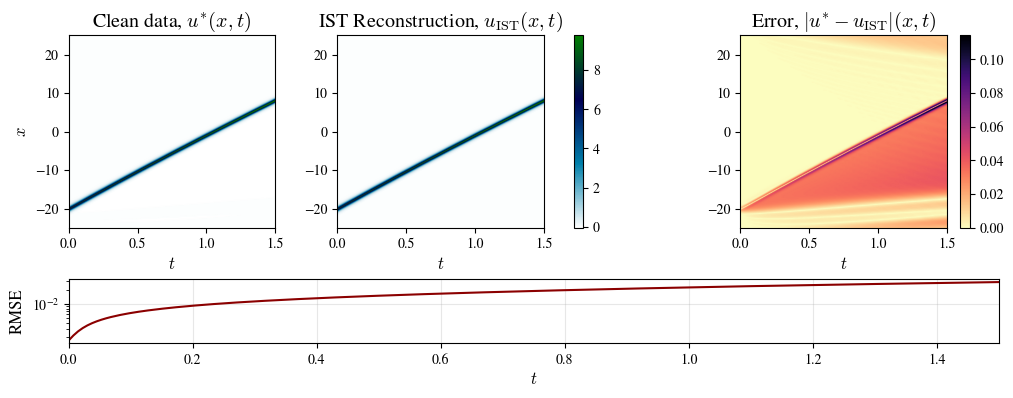

Total RMSE = 1.947e-02


In [19]:
# Forecast discovered model and IST to recover the field
x, _, U_star = load_kdv_field('outputs/kdv_single_soliton_perturbed_v0.nc')
total_rmse, rmse_t, U_IST = RMSE_of_forecast(stacked_states[0], U_star, x, t, coeffs, beta, plot=True)

print(f'Total RMSE = {total_rmse:.3e}')

#### **TWO-SOLITON COLLISION (PERTURBED)**

For a two KDV solitons forced by $F(u) = \epsilon (xu)_x$: $$\begin{align*}
  \begin{cases}
    \dot{\kappa}_i = \frac{1}{3}\epsilon\kappa_i + \mathcal{O}(\epsilon^2),\\
    \tfrac{d}{dt}\log(c_i) = 8\kappa^3_i - \frac{2}{3}\epsilon\log(c_i) + \mathcal{O}(\epsilon^2),
  \end{cases}
  \quad \text{for} \quad
  i = 1,2.
\end{align*}$$

In [20]:
import os

# Stack three perturbed two-soliton collision simulations
n_solitons = 2
config_files = ['outputs/kdv_soliton_collision_perturbed_v0.nc',  # (kappa_1, kappa_2) = (2.4, 1.2)
                'outputs/kdv_soliton_collision_perturbed_v1.nc',  # (kappa_1, kappa_2) = (2.0, 1.8)
                'outputs/kdv_soliton_collision_perturbed_v2.nc']  # (kappa_1, kappa_2) = (2.2, 1.4)

# Add noise?
noise = 0.0
#noise = 0.20

# Cache the data (only recomputes when noise changes)
cache = f'outputs/stacked_states_two_soliton_perturbed_noise{noise:g}.pt'
if os.path.exists(cache):
  blob = torch.load(cache)
  sim_states, t = blob['sim_states'], blob['t']
else:
  sim_states = []
  for path in config_files:
    x, t_np, U_star = load_kdv_field(path)
    states, _ = scattering_series_n(x, U_star, t_np, n_solitons, noise=noise, min_kappa=0.4)
    sim_states.append(states)
  t = torch.tensor(t_np, dtype=torch.float64)
  torch.save({'sim_states': sim_states, 't': t}, cache)

# Each soliton obeys the same perturbed (kappa, log c) law, so pool both solitons.
stacked_states = []
for states in sim_states:
  for i in range(n_solitons):
    stacked_states.append([states[i], states[n_solitons + i]])

In [21]:
names = [r'\kappa', r'\log(c)']
beta = [[1,0], [2,0], [3,0],
        [0,1], [0,2], [0,3]]

_, _, w_kappa = fit_wsindy_bic_stacked_eq(stacked_states, t, names, beta, eq=0, m=[20], p=[10], s=[1], rescale=False, trigger_BIC='poor_fit')
_, _, w_logc  = fit_wsindy_bic_stacked_eq(stacked_states, t, names, beta, eq=1, m=[20], p=[10], s=[1], rescale=False, trigger_BIC='poor_fit', Lambda=4e-2)

coeffs = [w_kappa, w_logc]

100%|██████████| 1/1 [00:00<00:00, 750.05it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 960
Num. terms = 6
cond(G) = 1.752e+06

RESULTS
ODE: \kappa_{t} = + 0.07(\kappa)
Nonzero terms = 1
Rel. L2 error = 0.116
R^2 = 0.842
Lambda = 9.103e-03
Loss = 0.216
gamma^2 = 16.085
BIC triggered = False
BIC Delta = n/a (not triggered)


<IPython.core.display.Math object>

100%|██████████| 1/1 [00:00<00:00, 549.06it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [1]
Not rescaled.

LIBRARY
Num. query points = 960
Num. terms = 6
cond(G) = 1.752e+06

RESULTS
ODE: \log(c)_{t} = - 0.14(\log(c)) + 8.02(\kappa^3)
Nonzero terms = 2
Rel. L2 error = 0.003
R^2 = 1.000
Lambda = 4.000e-02
Loss = 0.335
gamma^2 = 16.085
BIC triggered = False
BIC Delta = n/a (not triggered)


<IPython.core.display.Math object>

In [22]:
coeffs[0][0].item(), coeffs[1][0].item(), coeffs[1][5].item()

(0.06595112479086754, -0.13640922110368064, 8.019235534995353)

In [23]:
# Compare against the near-integrable scattering ODEs
eps = 0.2  # perturbation strength
w_true = [torch.tensor([eps/3, 0., 0., 0., 0., 0.]),    # kappa_t  = (eps/3) kappa
          torch.tensor([-2*eps/3, 0., 0., 0., 0., 8.])] # log(c)_t = -(2eps/3) log(c) + 8 k^3
w_found = torch.cat([w for w in coeffs])
w_truth = torch.cat(w_true)

# Known-model metrics
TPR = compute_tpr(w_found, w_truth)
nonzero = w_truth != 0
E_inf = ((w_found - w_truth).abs()[nonzero] / w_truth.abs()[nonzero]).max().item()

print(f'TPR = {TPR:.3f}')
print(f'E_inf = {E_inf:.3e}')

TPR = 1.000
E_inf = 2.307e-02


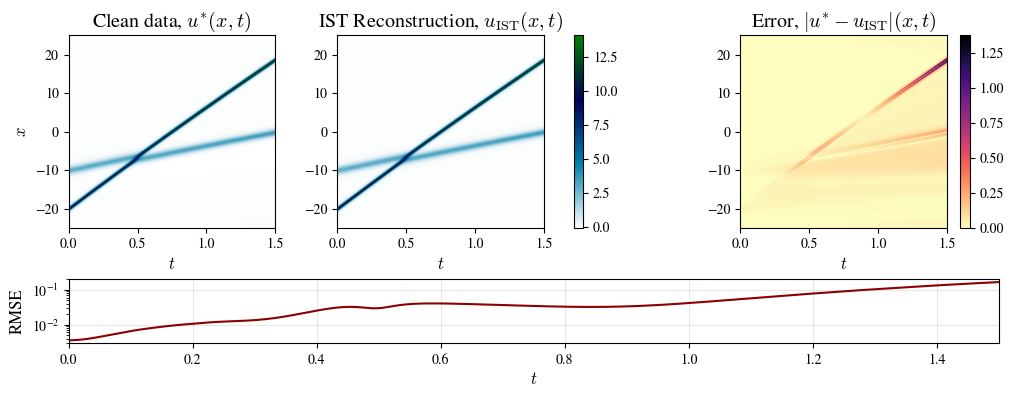

Total RMSE = 6.405e-02


In [24]:
# Forecast discovered model and IST to recover the field
x, _, U_star = load_kdv_field('outputs/kdv_soliton_collision_perturbed_v0.nc')
total_rmse, rmse_t, U_IST = RMSE_of_forecast_pooled(sim_states[0], U_star, x, t, coeffs, beta, n_solitons, plot=True)

print(f'Total RMSE = {total_rmse:.3e}')